In [1]:
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
X = pd.read_csv("data/individuals_dataset_cleaned.csv")
id = X['ID']
weight = X['WEIGHT_INDIV']
codgeo = X['CODGEO']
X = X.drop(columns=['ID', 'WEIGHT_INDIV', 'GPS_RECORD', 'CODGEO'])

In [6]:
n_components = 10  # number of clusters/components
model = NMF(n_components=n_components, init='random', random_state=42)
W = model.fit_transform(X)

/home/juan/miniconda3/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


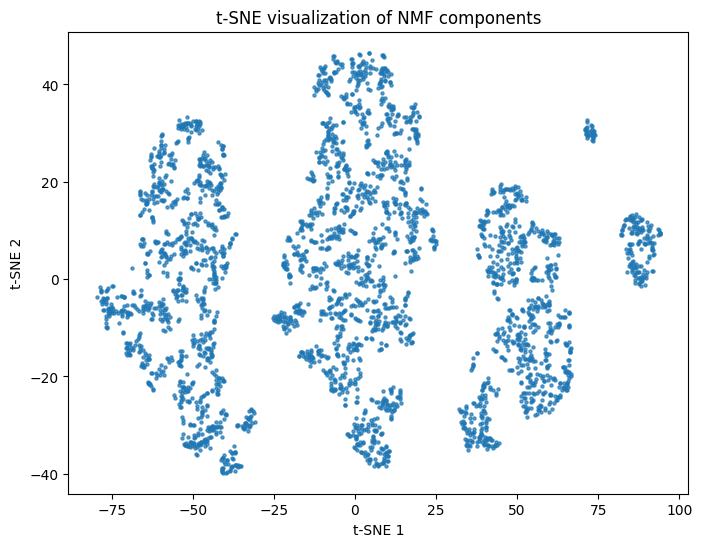

In [4]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
W_tsne = tsne.fit_transform(W)

plt.figure(figsize=(8, 6))
plt.scatter(W_tsne[:, 0], W_tsne[:, 1], s=5, alpha=0.7)
plt.title("t-SNE visualization of NMF components")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [7]:
# Create a DataFrame for NMF components
W_df = pd.DataFrame(W, columns=[f'NMF_{i+1}' for i in range(n_components)])

# Concatenate ID, NMF components, weight, and codgeo
nmf_dataset = pd.concat([id.reset_index(drop=True), W_df, weight.reset_index(drop=True), codgeo.reset_index(drop=True)], axis=1)
nmf_dataset.columns = ['ID'] + [f'NMF_{i+1}' for i in range(n_components)] + ['WEIGHT_INDIV', 'CODGEO']

# Save to CSV
nmf_dataset.to_csv("nmf_individuals_dataset.csv", index=False)